In [1]:
!pip install yfinance scikit-learn


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:

ticker = "AAPL"
df = yf.download(ticker, start="2022-01-01", end="2024-01-01")

print("Data Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

[*********************100%***********************]  1 of 1 completed

Data Shape: (501, 5)

First 5 rows:


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,178.103638,178.954976,173.895938,174.013357,104487900
2022-01-04,175.843262,179.013730,175.275708,178.710386,99310400
2022-01-05,171.165817,176.303140,170.891828,175.755162,94537600
2022-01-06,168.308517,171.537695,167.956243,168.993491,96904000
2022-01-07,168.474854,170.402574,167.359321,169.179402,86709100


In [4]:
print("Column Names:", df.columns.tolist())
print("\nData Info:")
df.info()

Column Names: [('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL')]

Data Info:
<class 'pandas.DataFrame'>
DatetimeIndex: 501 entries, 2022-01-03 to 2023-12-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   501 non-null    float64
 1   (High, AAPL)    501 non-null    float64
 2   (Low, AAPL)     501 non-null    float64
 3   (Open, AAPL)    501 non-null    float64
 4   (Volume, AAPL)  501 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 23.5 KB


In [5]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,501.000000,501.000000,501.000000,501.000000,5.010000e+02
mean,161.129996,162.793584,159.304204,160.970299,7.359559e+07
std,17.727055,17.459410,17.989136,17.759345,2.536654e+07
min,123.046806,125.753403,122.210234,124.021209,2.404830e+07
25%,146.783539,148.390487,144.907187,146.271103,5.414710e+07
50%,162.036774,163.235219,159.714674,161.644831,6.924600e+07
75%,174.040314,175.522950,172.132663,174.013357,8.670910e+07
max,196.073135,197.567605,194.974489,195.984064,1.826020e+08


In [6]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


In [7]:


df = df.copy()
df['Target'] = df['Close'].shift(-1)  # next day close price


df.dropna(inplace=True)

print("Shape after feature engineering:", df.shape)
df[['Open', 'High', 'Low', 'Close', 'Volume', 'Target']].head()

Shape after feature engineering: (500, 6)


Price,Open,High,Low,Close,Volume,Target
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2022-01-03,174.013357,178.954976,173.895938,178.103638,104487900,175.843262
2022-01-04,178.710386,179.013730,175.275708,175.843262,99310400,171.165817
2022-01-05,175.755162,176.303140,170.891828,171.165817,94537600,168.308517
2022-01-06,168.993491,171.537695,167.956243,168.308517,96904000,168.474854
2022-01-07,169.179402,170.402574,167.359321,168.474854,86709100,168.494415


In [8]:
features = ['Open', 'High', 'Low', 'Close', 'Volume']

X = df[features].values
y = df['Target'].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (500, 5)
y shape: (500,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # time series mein shuffle=False zaroori hai
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 400
Testing samples: 100


In [10]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

print("Linear Regression Results:")
print(f"  MAE  : {mean_absolute_error(y_test, lr_predictions):.4f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, lr_predictions)):.4f}")
print(f"  R²   : {r2_score(y_test, lr_predictions):.4f}")

Linear Regression Results:
  MAE  : 1.7238
  RMSE : 2.1370
  R²   : 0.9345


In [11]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest Results:")
print(f"  MAE  : {mean_absolute_error(y_test, rf_predictions):.4f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, rf_predictions)):.4f}")
print(f"  R²   : {r2_score(y_test, rf_predictions):.4f}")

Random Forest Results:
  MAE  : 1.9810
  RMSE : 2.5184
  R²   : 0.9090


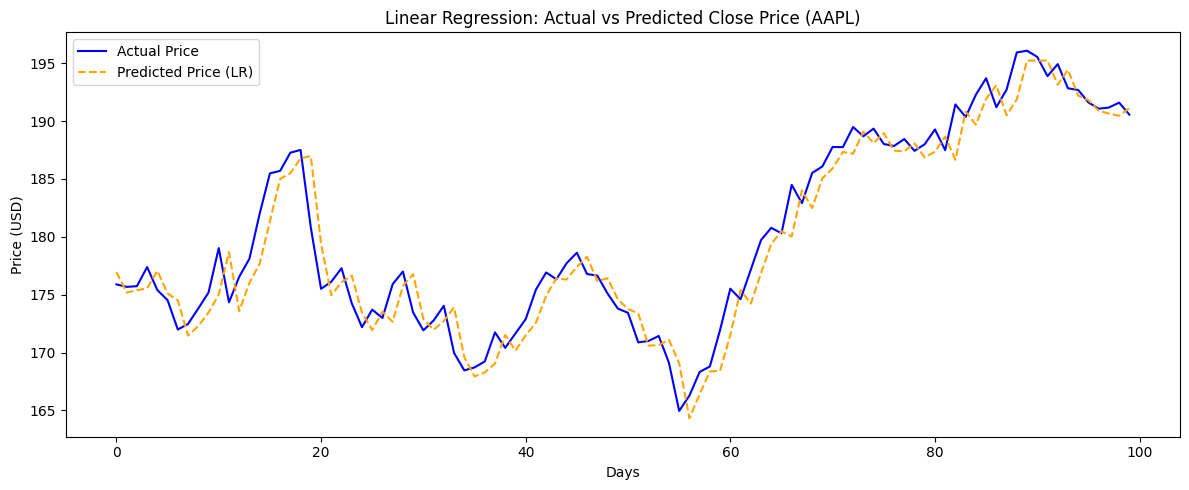

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(y_test, label='Actual Price', color='blue', linewidth=1.5)
plt.plot(lr_predictions, label='Predicted Price (LR)', color='orange', linewidth=1.5, linestyle='--')
plt.title('Linear Regression: Actual vs Predicted Close Price (AAPL)')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

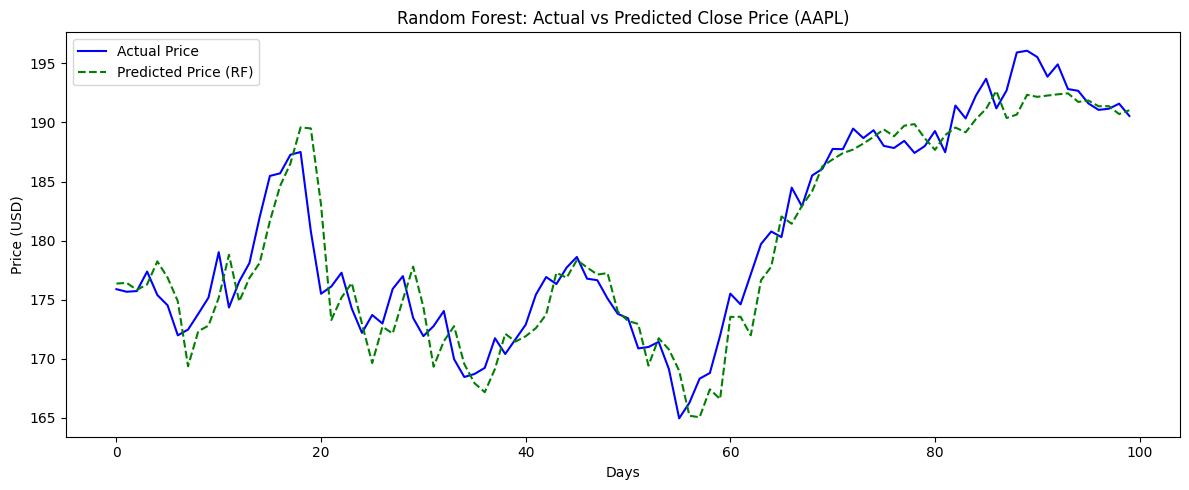

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(y_test, label='Actual Price', color='blue', linewidth=1.5)
plt.plot(rf_predictions, label='Predicted Price (RF)', color='green', linewidth=1.5, linestyle='--')
plt.title('Random Forest: Actual vs Predicted Close Price (AAPL)')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

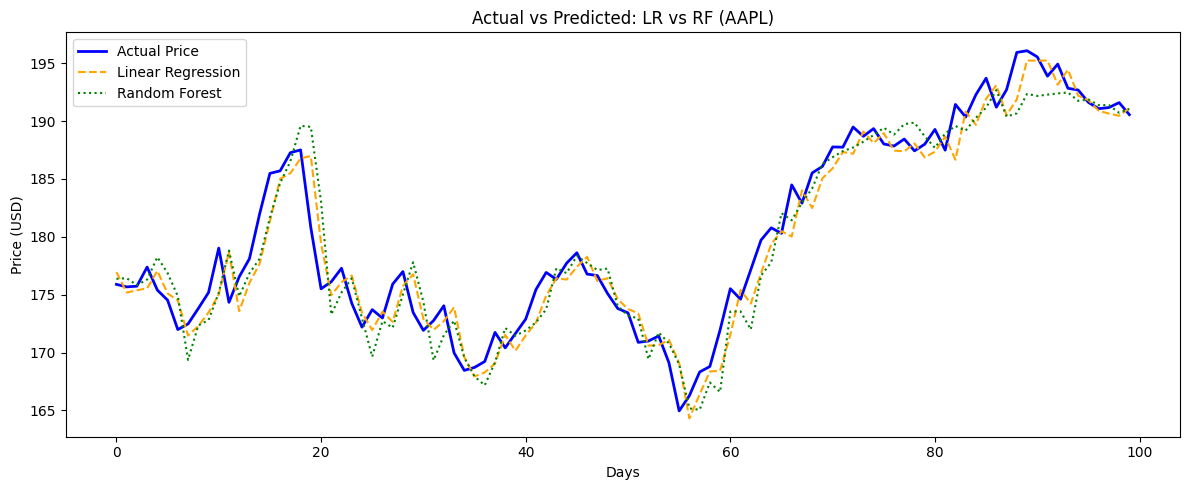

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(y_test, label='Actual Price', color='blue', linewidth=2)
plt.plot(lr_predictions, label='Linear Regression', color='orange', linewidth=1.5, linestyle='--')
plt.plot(rf_predictions, label='Random Forest', color='green', linewidth=1.5, linestyle=':')
plt.title('Actual vs Predicted: LR vs RF (AAPL)')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

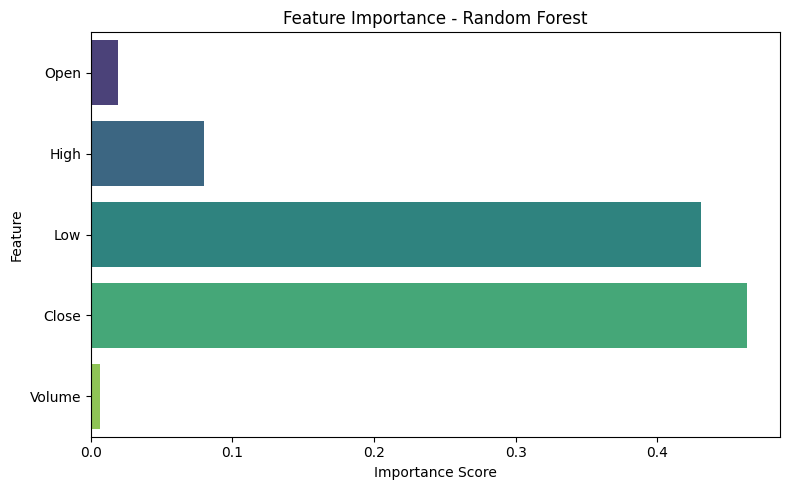

In [18]:
feature_names = ['Open', 'High', 'Low', 'Close', 'Volume']
importances = rf_model.feature_importances_

plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=feature_names, hue=feature_names, palette='viridis', legend=False)
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [17]:
print("=" * 50)
print("MODEL COMPARISON SUMMARY — AAPL Stock")
print("=" * 50)

print(f"\nLinear Regression:")
print(f"  R² Score : {r2_score(y_test, lr_predictions):.4f}")
print(f"  MAE      : {mean_absolute_error(y_test, lr_predictions):.4f}")

print(f"\nRandom Forest:")
print(f"  R² Score : {r2_score(y_test, rf_predictions):.4f}")
print(f"  MAE      : {mean_absolute_error(y_test, rf_predictions):.4f}")

print("\nConclusion:")
if r2_score(y_test, rf_predictions) > r2_score(y_test, lr_predictions):
    print("  Random Forest performed BETTER than Linear Regression!")
else:
    print("  Linear Regression performed BETTER than Random Forest!")

MODEL COMPARISON SUMMARY — AAPL Stock

Linear Regression:
  R² Score : 0.9345
  MAE      : 1.7238

Random Forest:
  R² Score : 0.9090
  MAE      : 1.9810

Conclusion:
  Linear Regression performed BETTER than Random Forest!
